In [5]:
!pip install python-docx

from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH


def create_report():
    doc = Document()

    # Title
    title = doc.add_heading(
        'Project Report: Unsupervised Multimodal Anomaly Detection',
        level=0
    )

    title.alignment = WD_ALIGN_PARAGRAPH.CENTER

    # Executive Summary
    doc.add_heading('1. Executive Summary', level=1)

    doc.add_paragraph(
        "This report details the implementation of a deep multimodal anomaly detection framework "
        "adapted for the NASA C-MAPSS turbofan engine dataset. The primary challenge is "
        "accurately diagnosing system health when sensors fail or data is dropped. Instead of being "
        "used for Remaining Useful Life (RUL) estimation, this framework relies on learning a "
        "steady-state operational baseline."
    )

    # Conceptual Insights
    doc.add_heading('2. Conceptual Insights & Architecture', level=1)

    doc.add_paragraph(
        "The architecture is defined by three distinct fusion mechanisms:\n\n"
        "• Intramodality Fusion: C-MAPSS sensors are grouped into physical modalities. "
        "When a sensor drops out, the model utilizes an adaptive softmax weighting mechanism "
        "to reconstruct the missing data in the latent space.\n"
        "• Intermodality Fusion: Cross-sensor correlations (e.g., how fan speed affects pressure) "
        "are learned using a skip-connected Autoencoder. This generates the secondary reconstruction.\n"
        "• Decision Fusion: Time-series signals are bisected and scored independently "
        "to minimize variance and combat overfitting."
    )

    # Mathematical Novelty
    doc.add_heading('3. The Anomaly Score Formulation', level=1)

    doc.add_paragraph(
        "A standard autoencoder refactors latent spaces to align them. The UU-Net instead "
        "minimizes the reconstruction errors (R1 and R2) while mathematically separating the latent "
        "representations of the first and second modules (Dz). This creates a highly sensitive manifold for abnormal "
        "data, making the model highly sensitive to engine degradation markers."
    )

    # Implementation Steps
    doc.add_heading('4. Python Implementation Steps', level=1)

    steps = doc.add_paragraph()

    steps.add_run("Step 1: Data Preprocessing. ").bold = True
    steps.add_run(
        "1D time-series windows of the C-MAPSS data are encoded into 2D Gramian Angular Field (GAF) images."
    )

    steps.add_run("Step 2: Modality Masking. ").bold = True
    steps.add_run(
        "During PyTorch training, a 'missing_mask' is generated to randomly remove sensor channels."
    )

    steps.add_run("Step 3: Thresholding via KDE. ").bold = True
    steps.add_run(
        "Kernel Density Estimation is used on the training loss scores to determine anomaly thresholds."
    )

    # Save the document
    file_name = 'C-MAPSS_UUNet_Implementation_Report.docx'

    doc.save(file_name)

    print(f"Report successfully generated and saved as '{file_name}'")


if __name__ == "__main__":
    create_report()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.1 MB/s eta 0:00:00
Report successfully generated and saved as 'C-MAPSS_UUNet_Implementation_Report.docx'


<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_25961/1574422793.py:22: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


Loading dataset...
Generating Sensor Degradation Plot...


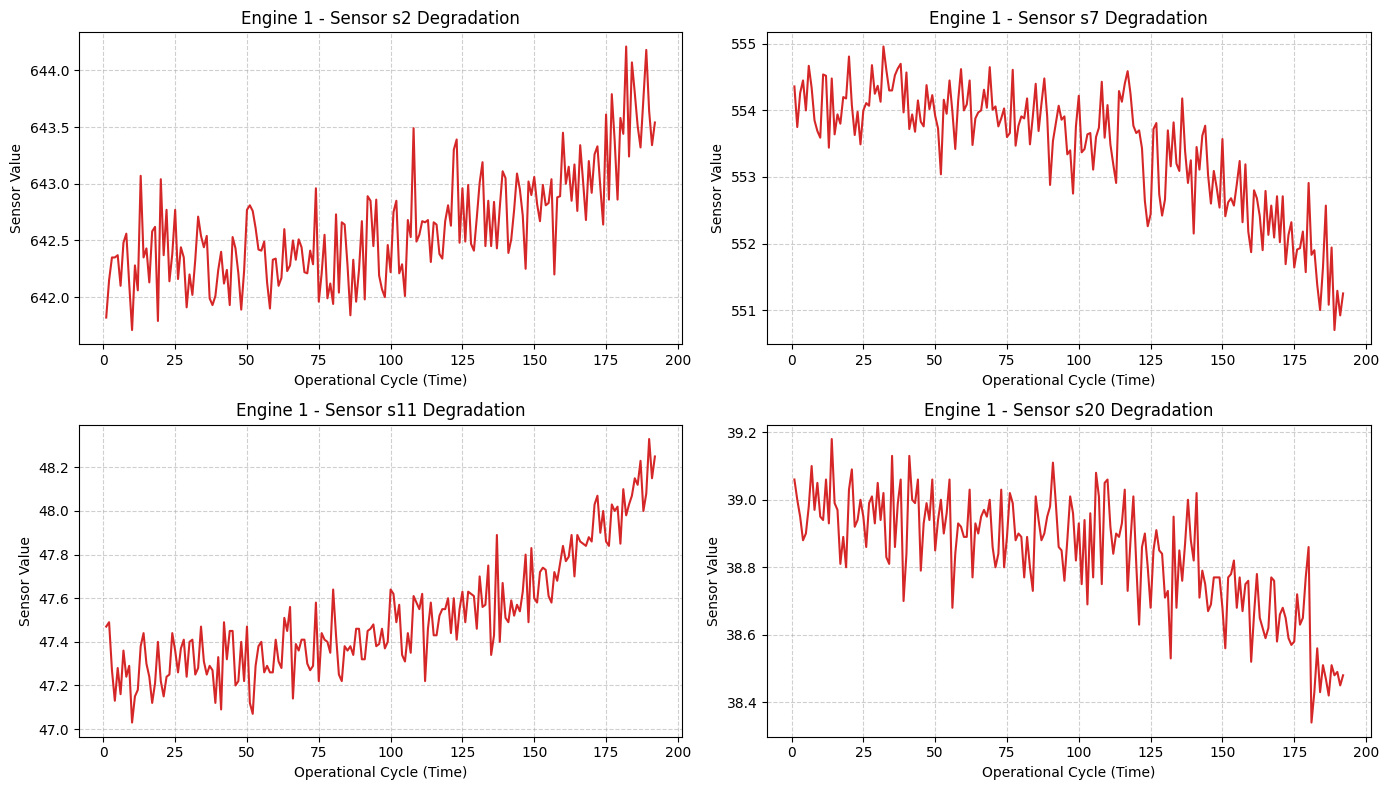

Generating Engine Lifetime Distribution Plot...


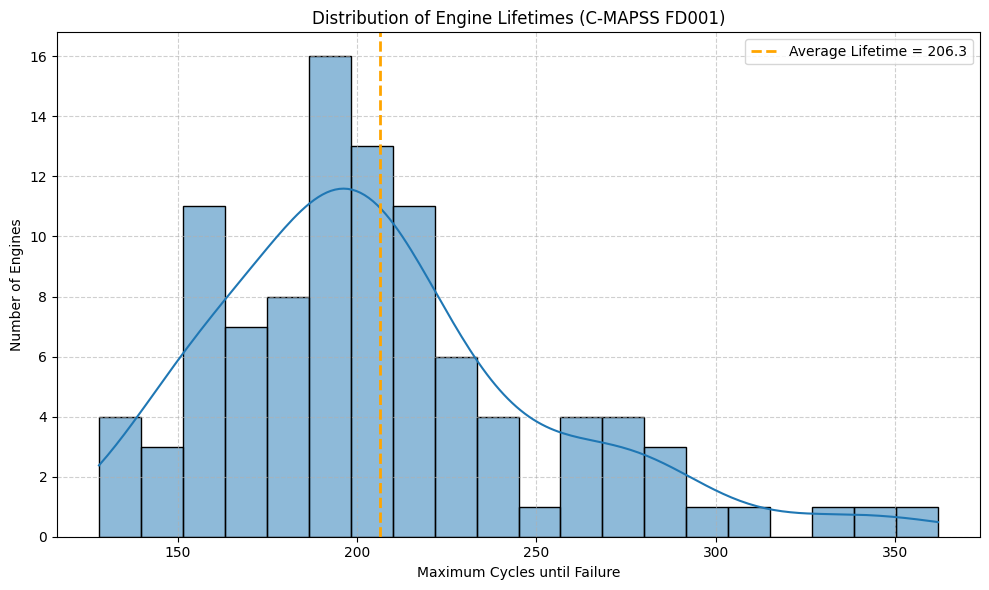

Generating Gramian Angular Field Transformation Plot...


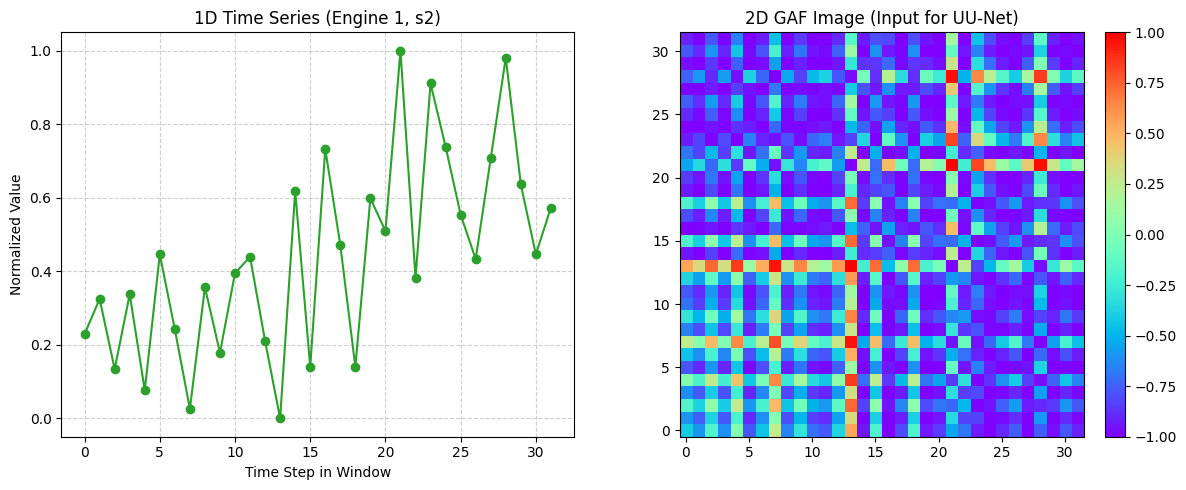

Plots have been displayed and saved as PNG files in your directory.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyts.image import GramianAngularField

# ==========================================
# 1. Load and Prepare C-MAPSS Data
# ==========================================

def load_cmapss_data(file_path):
    """Loads the C-MAPSS dataset and assigns column names."""

    columns = ['unit', 'cycle', 'op_setting1', 'op_setting2', 'op_setting3'] + [
        f's{i}' for i in range(1, 22)
    ]

    try:
        df = pd.read_csv(
            file_path,
            sep='\s+',
            header=None,
            names=columns
        )

        return df

    except FileNotFoundError:
        print(
            f"Error: Could not find '{file_path}'. Please ensure the C-MAPSS dataset exists."
        )

        return None


# ==========================================
# 2. Plotting Functions
# ==========================================

def plot_sensor_degradation(df, engine_id=1):
    """Plots the degradation of key sensors over the lifetime of a specific engine."""

    engine_data = df[df['unit'] == engine_id]

    # Select representative sensors
    # (s2: Temperature, s7: Pressure, s20: Mechanical/Bleed)

    sensors_to_plot = ['s2', 's7', 's11', 's20']

    plt.figure(figsize=(14, 8))

    for i, sensor in enumerate(sensors_to_plot, 1):

        plt.subplot(2, 2, i)

        plt.plot(
            engine_data['cycle'],
            engine_data[sensor],
            color='tab:red'
        )

        plt.title(f'Engine {engine_id} - Sensor {sensor} Degradation')

        plt.xlabel('Operational Cycle (Time)')
        plt.ylabel('Sensor Value')

        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    plt.savefig('sensor_degradation.png')

    plt.show()


def plot_engine_lifetimes(df):
    """Plots a histogram of the maximum lifetime (cycles) for all engines."""

    # Find maximum cycle (lifetime) for each engine unit
    lifetimes = df.groupby('unit')['cycle'].max()

    plt.figure(figsize=(10, 6))

    sns.histplot(
        lifetimes,
        bins=20,
        kde=True,
        color='tab:blue'
    )

    plt.title('Distribution of Engine Lifetimes (C-MAPSS FD001)')

    plt.xlabel('Maximum Cycles until Failure')
    plt.ylabel('Number of Engines')

    plt.grid(True, linestyle='--', alpha=0.6)

    # Add a vertical line for average lifetime
    plt.axvline(
        lifetimes.mean(),
        color='orange',
        linestyle='dashed',
        linewidth=2,
        label=f'Average Lifetime = {lifetimes.mean():.1f}'
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig('engine_lifetimes.png')

    plt.show()


def plot_gaf_transformation(df, engine_id=1, sensor='s2', window_size=32):
    """Visualizes the 1D to 2D Gramian Angular Field transformation for UU-Net."""

    engine_data = df[df['unit'] == engine_id][sensor].values

    # Take last window_size cycles
    time_series_window = engine_data[-window_size:]

    # Normalize between 0 and 1
    ts_normalized = (
        (time_series_window - np.min(time_series_window))
        /
        (np.max(time_series_window) - np.min(time_series_window))
    )

    # Apply GAF
    gaf = GramianAngularField(
        image_size=window_size,
        method='summation'
    )

    gaf_image = gaf.fit_transform(
        ts_normalized.reshape(1, -1)
    )[0]

    # Side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1D Time Series
    axes[0].plot(
        range(window_size),
        ts_normalized,
        marker='o',
        color='tab:green'
    )

    axes[0].set_title(
        f'1D Time Series (Engine {engine_id}, {sensor})'
    )

    axes[0].set_xlabel('Time Step in Window')
    axes[0].set_ylabel('Normalized Value')

    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Plot 2D GAF Image
    img = axes[1].imshow(
        gaf_image,
        cmap='rainbow',
        origin='lower'
    )

    axes[1].set_title('2D GAF Image (Input for UU-Net)')

    fig.colorbar(
        img,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )

    plt.tight_layout()

    plt.savefig('gaf_transformation.png')

    plt.show()


# ==========================================
# 3. Main Execution
# ==========================================

if __name__ == "__main__":

    # Ensure 'train_FD001.txt' is in same directory
    dataset_path = 'train_FD001.txt'

    print("Loading dataset...")

    cmapss_df = load_cmapss_data(dataset_path)

    if cmapss_df is not None:

        print("Generating Sensor Degradation Plot...")
        plot_sensor_degradation(cmapss_df, engine_id=1)

        print("Generating Engine Lifetime Distribution Plot...")
        plot_engine_lifetimes(cmapss_df)

        print("Generating Gramian Angular Field Transformation Plot...")
        plot_gaf_transformation(
            cmapss_df,
            engine_id=1,
            sensor='s2',
            window_size=32
        )

        print("Plots have been displayed and saved as PNG files in your directory.")